## Name: Jonathan Steen
## Assignment: 11.2
## Date: 11/13/2022
## Course: DSC550

In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow import keras
from keras import utils as np_utils
from keras import backend as kBackend
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers.convolutional import Conv2D, MaxPooling2D
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

2022-11-19 12:19:31.574816: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
os.chdir('/Users/jonsteen/Desktop/DSC550 - Fall 2022')

In [3]:
# Load MNIST data
(xTrain, yTrain), (xTest, yTest) = mnist.load_data()

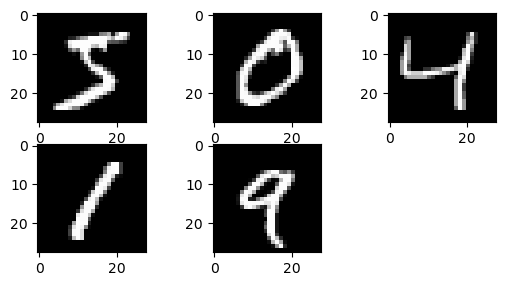

In [4]:
# Display first 5 images
for i in range(5):
    pyplot.subplot(330 + 1 + i)
    pyplot.imshow(xTrain[i], cmap = pyplot.get_cmap('gray'))
pyplot.show()

In [5]:
# Set seed
np.random.seed(0)

In [6]:
# Set image information
channels = 1
height = 28
width = 28

In [7]:
# Reshape to a single channel
xTrain = xTrain.reshape((xTrain.shape[0], 28, 28, 1))
xTest = xTest.reshape((xTest.shape[0], 28, 28, 1))

In [8]:
# Rescale pixel intensity
trainFeatures = xTrain / 255
testFeatures = xTest / 255

In [9]:
# Encode target - y
yTrain = keras.utils.to_categorical(yTrain)
yTest = keras.utils.to_categorical(yTest)
classes = yTest.shape[1]

In [10]:
# Start neural network
neuralNet = Sequential()

2022-11-19 12:19:35.738245: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [11]:
# Add convolutional layer
neuralNet.add(Conv2D(
    filters = 64, 
    kernel_size = (5, 5), 
    input_shape = (height, width, channels), 
    activation = 'relu'))

In [12]:
# Add max pooling layer
neuralNet.add(MaxPooling2D(pool_size = (2, 2)))

In [13]:
# Add dropout layer
neuralNet.add(Dropout(0.5))

In [14]:
# Flatten input
neuralNet.add(Flatten())

In [15]:
# Add connected layer - 128 units - ReLU
neuralNet.add(Dense(128, activation = "relu"))

In [16]:
# Add dropout layer
neuralNet.add(Dropout(0.5))

In [17]:
# Add connected layer - softmax
neuralNet.add(Dense(classes, activation = "softmax"))

In [18]:
# Compile neural network
neuralNet.compile(
    loss = "categorical_crossentropy", 
    optimizer = "rmsprop", 
    metrics = ["accuracy"])

In [19]:
# Train neural network
neuralNet.fit(
    trainFeatures,
    yTrain,
    epochs = 2,
    verbose = 0,
    batch_size = 1000,
    validation_data = (testFeatures, yTest))

In [20]:
neuralNet.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 24, 24, 64)        1664      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 12, 12, 64)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 12, 12, 64)        0         
                                                                 
 flatten (Flatten)           (None, 9216)              0         
                                                                 
 dense (Dense)               (None, 128)               1179776   
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                        

In [21]:
# Make predictions on test set
predictions = neuralNet.predict(xTest)

313/313 [==============================] - 1s 2ms/step


In [22]:
# Convert values for confusion matrix
yPredictions = np.argmax(predictions, axis = 1)

In [23]:
# Convert values for confusion matrix
yTrue = np.argmax(yTest, axis = 1)

In [24]:
# Calculate and print stats
accuracy = accuracy_score(yTrue, yPredictions)
precision = precision_score(yTrue, yPredictions, average = 'micro')
recall = recall_score(yTrue, yPredictions, average = 'micro')
f1 = f1_score(yTrue, yPredictions, average = 'micro')

In [25]:
# Print classification report
print(classification_report(yTrue, yPredictions))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.95      0.97      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.97      0.99      0.98       958
           7       0.97      0.96      0.96      1028
           8       0.98      0.95      0.96       974
           9       0.95      0.97      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



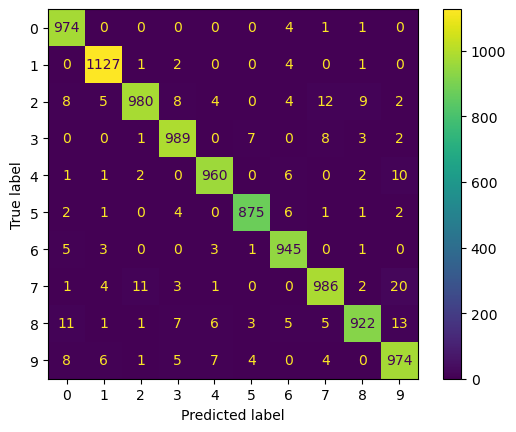

In [26]:
# Display confusion matrix
cm = confusion_matrix(yTrue, yPredictions)

cmDisplay = ConfusionMatrixDisplay(
    confusion_matrix = cm, 
    display_labels = [0,1,2,3,4,5,6,7,8,9])

cmDisplay.plot()
pyplot.show()

The test set accuracy is 97%. With most of the classifications the predicted value matches the actual or true value. This lines up with the high accuracy.